# Fourier Coefficients: Period $\to$ Aperiodic

## As $T_0$ increases the $\omega$ gap shrinks

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

import sympy as sp
from sympy import Symbol, oo, integrate 
from sympy import lambdify, Symbol, integrate
print("Running Sympy:",sp.__version__)
ts = Symbol('t')

from ipywidgets import interactive
from IPython.display import HTML

from lcapy import Circuit, j, omega, s, exp, t, u, delta
from lcapy import R, C, L

Kbase = 4 # scaling used in plotting

def H(t):
    return np.heaviside(t, 1)

Running Sympy: 1.13.3


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Plotting functions

In [4]:
def compute_ck(T0,xftn):
    omega0 = 2*np.pi/T0
    tt = np.arange(-T0/2, T0/2, 1/10000)  # the time samples
    x2 = lambda t,k: np.exp(-1j*k*omega0*t)  
    prod = lambda t,k: xftn(t) * x2(t,k)/T0

    Cvalues = np.zeros((2*KK+1,1),dtype = 'complex_')
    for kk in Krange:
        Cvalues[KK+kk] = sc.integrate.simpson(prod(tt,kk), tt)
    return Cvalues

def plot_fourier_coeffs(T0,x,Cvals):
    omega0 = 2*np.pi/T0
    plot_tt = np.arange(-3*T0, 3*T0, 1/100)  # the time samples
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,5), dpi=300)
    ax1.plot(plot_tt, x(plot_tt), 'k-', lw=2)
    ax1.set_title('Function')
    ax1.set_ylabel('$x(t)$')
    ax1.set_xlabel('$t$')
    bm.nicegrid(ax1)
    
    markerline, stemlines, baseline = ax2.stem(Krange*omega0, T0*Cvals.real, 'b-')
    plt.setp(stemlines, 'linewidth', 0.5)
    plt_omega = np.arange(min(Krange*omega0),max(Krange*omega0),1/1000)
    ax2.plot(plt_omega,np.sinc(plt_omega/2/np.pi),'r--')
    ax2.set_xlabel('$\omega$')
    ax2.set_title('Fourier Coefficients')
    ax2.set_ylabel('$T_0 c_k $')
    ax2.set_ylim(-0.4,1.25)
    ax2.text(-3*T0*omega0,0.8,'$T_0 = $'+str(T0))
    ax2.text(-3*T0*omega0,0.6,'$\omega_0=2\pi/$'+str(T0))
    ax2.set_xticks((-2*T0*omega0,-T0*omega0,0,T0*omega0,2*T0*omega0)) 
    ax2.set_xticklabels(['-'+str(2*T0)+'$\omega_0$','-'+str(T0)+'$\omega_0$',0,str(T0)+'$\omega_0$',str(2*T0)+'$\omega_0$'])
    plt.tight_layout()
    bm.nicegrid(ax2)
    plt.show()

def square_wave_for_period(T0):
    return lambda t: (1 + sc.signal.square(2*np.pi*(t + 1/2)/T0, 1/T0)) / 2

def plot_square_wave_coeffs(T0):
    global KK, Krange
    KK = Kbase * T0
    Krange = np.arange(-KK, KK + 1, 1)

    x4 = square_wave_for_period(T0)
    C_ex4 = compute_ck(T0, x4)
    plot_fourier_coeffs(T0, x4, C_ex4)
    return C_ex4


## Fourier Coeffs for Square Wave with various periods  

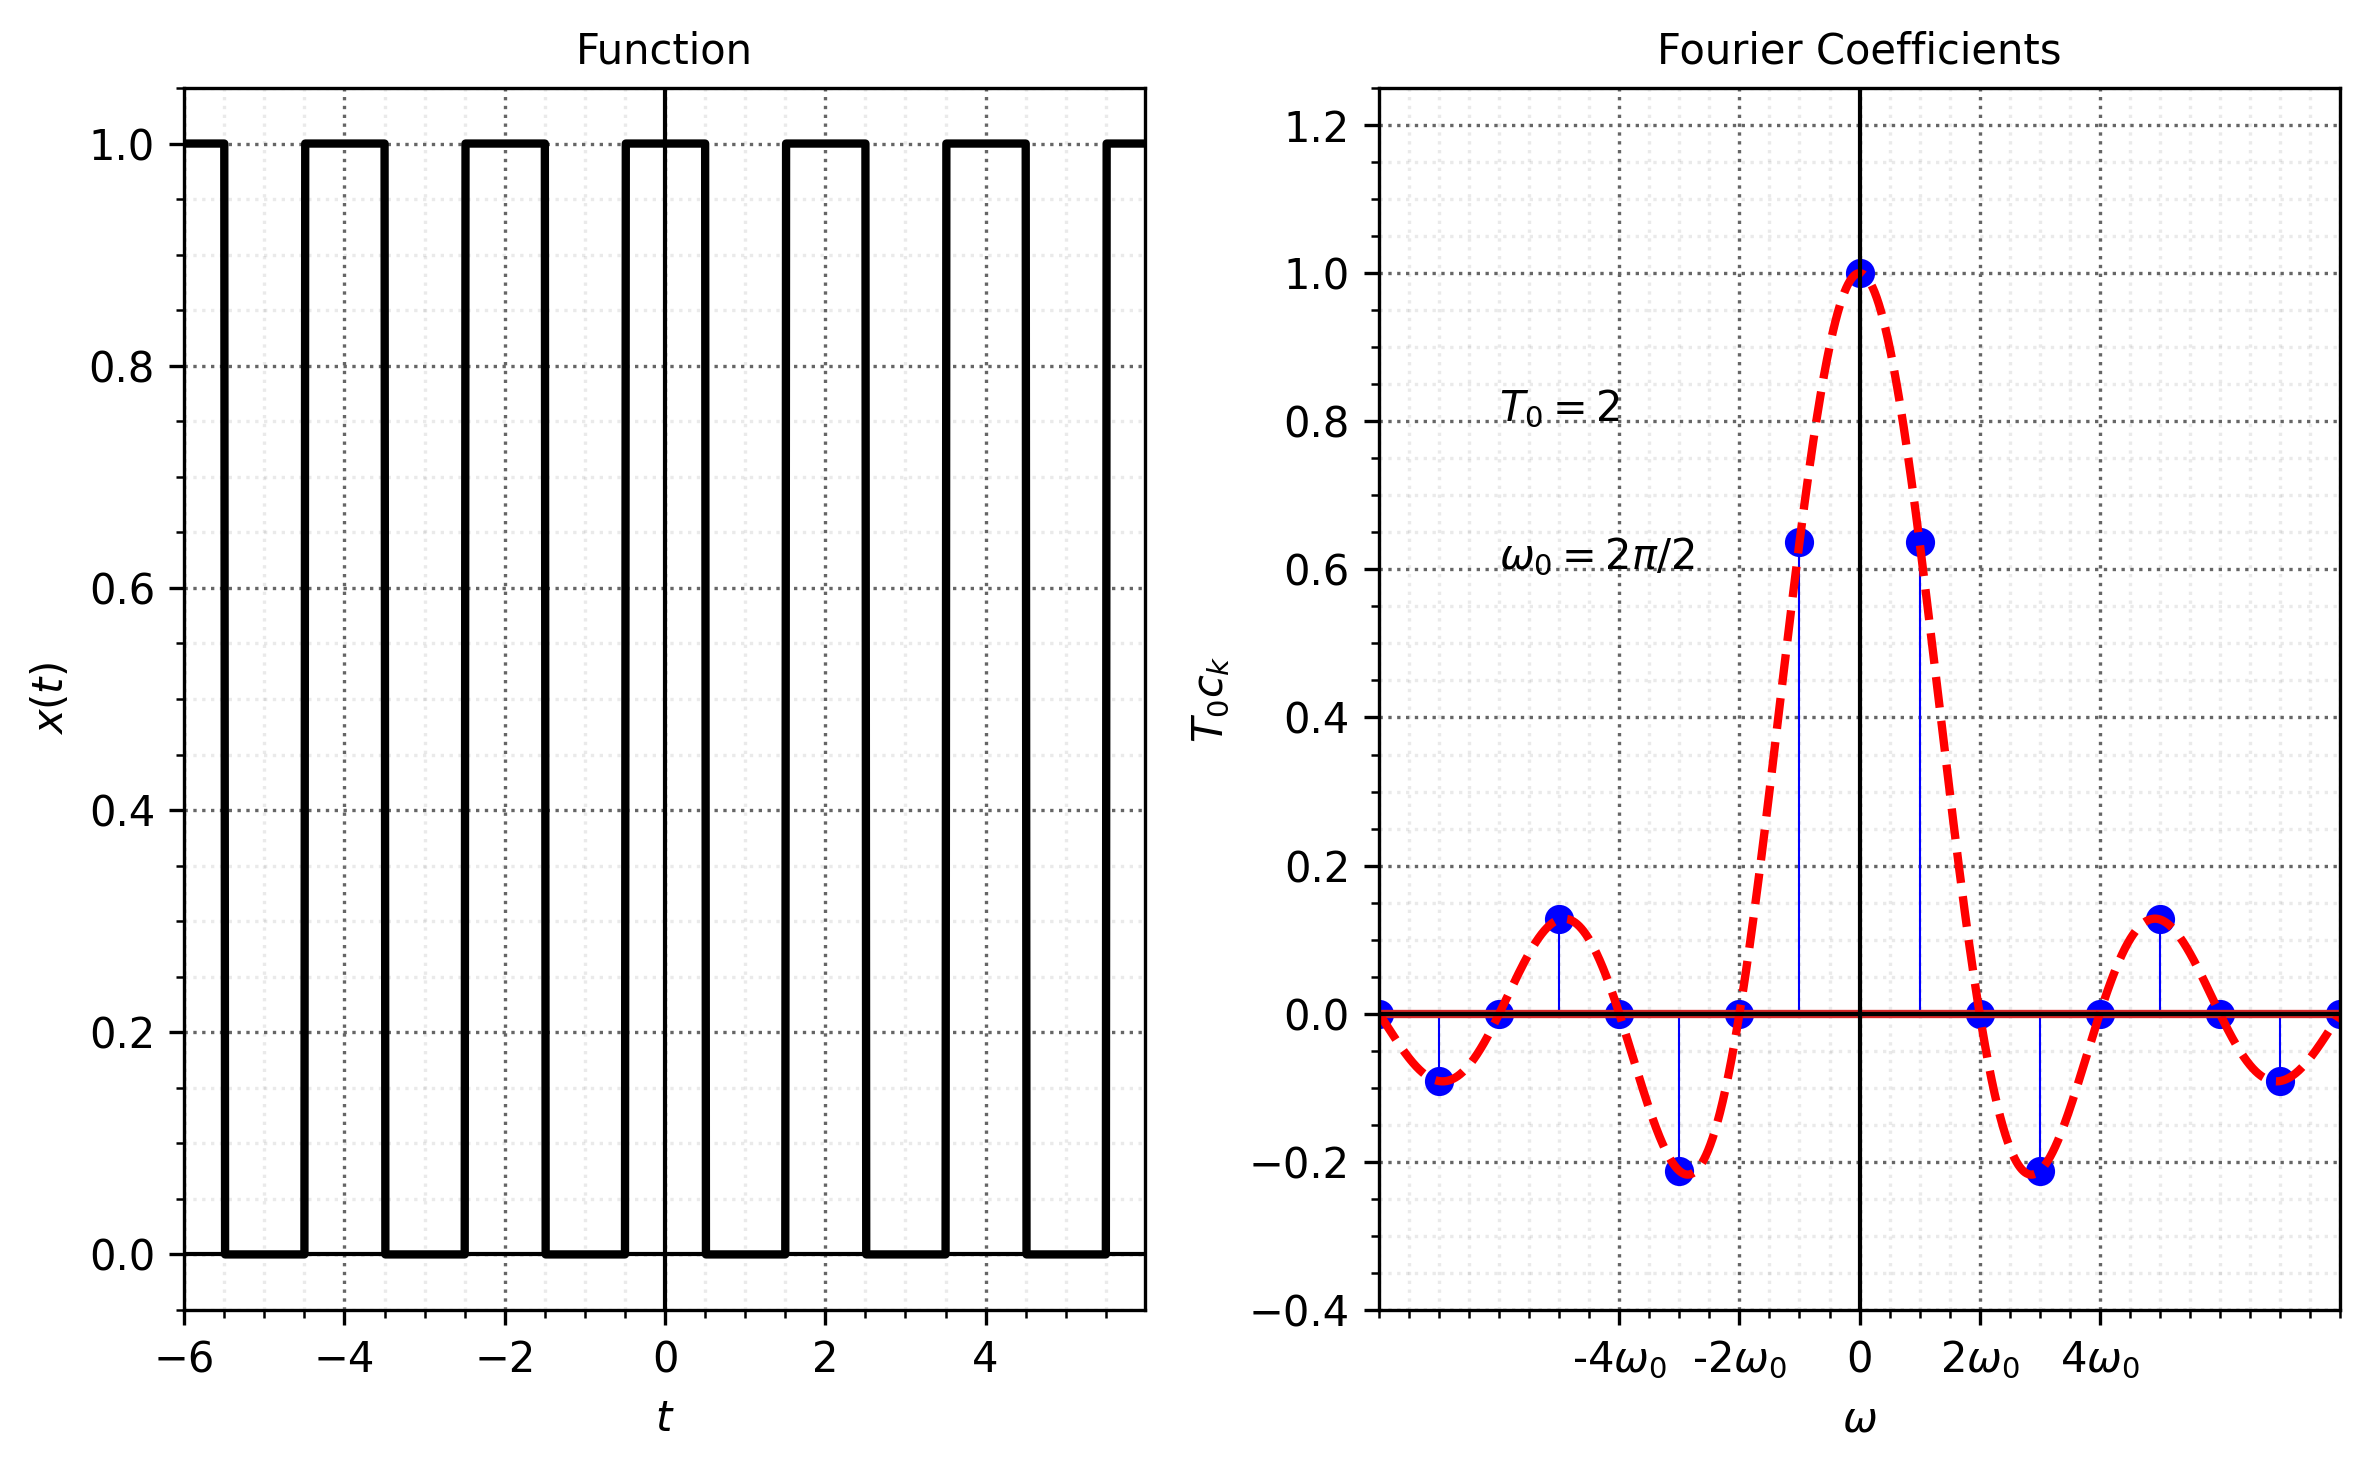

In [5]:
C_ex4 = plot_square_wave_coeffs(T0=2)

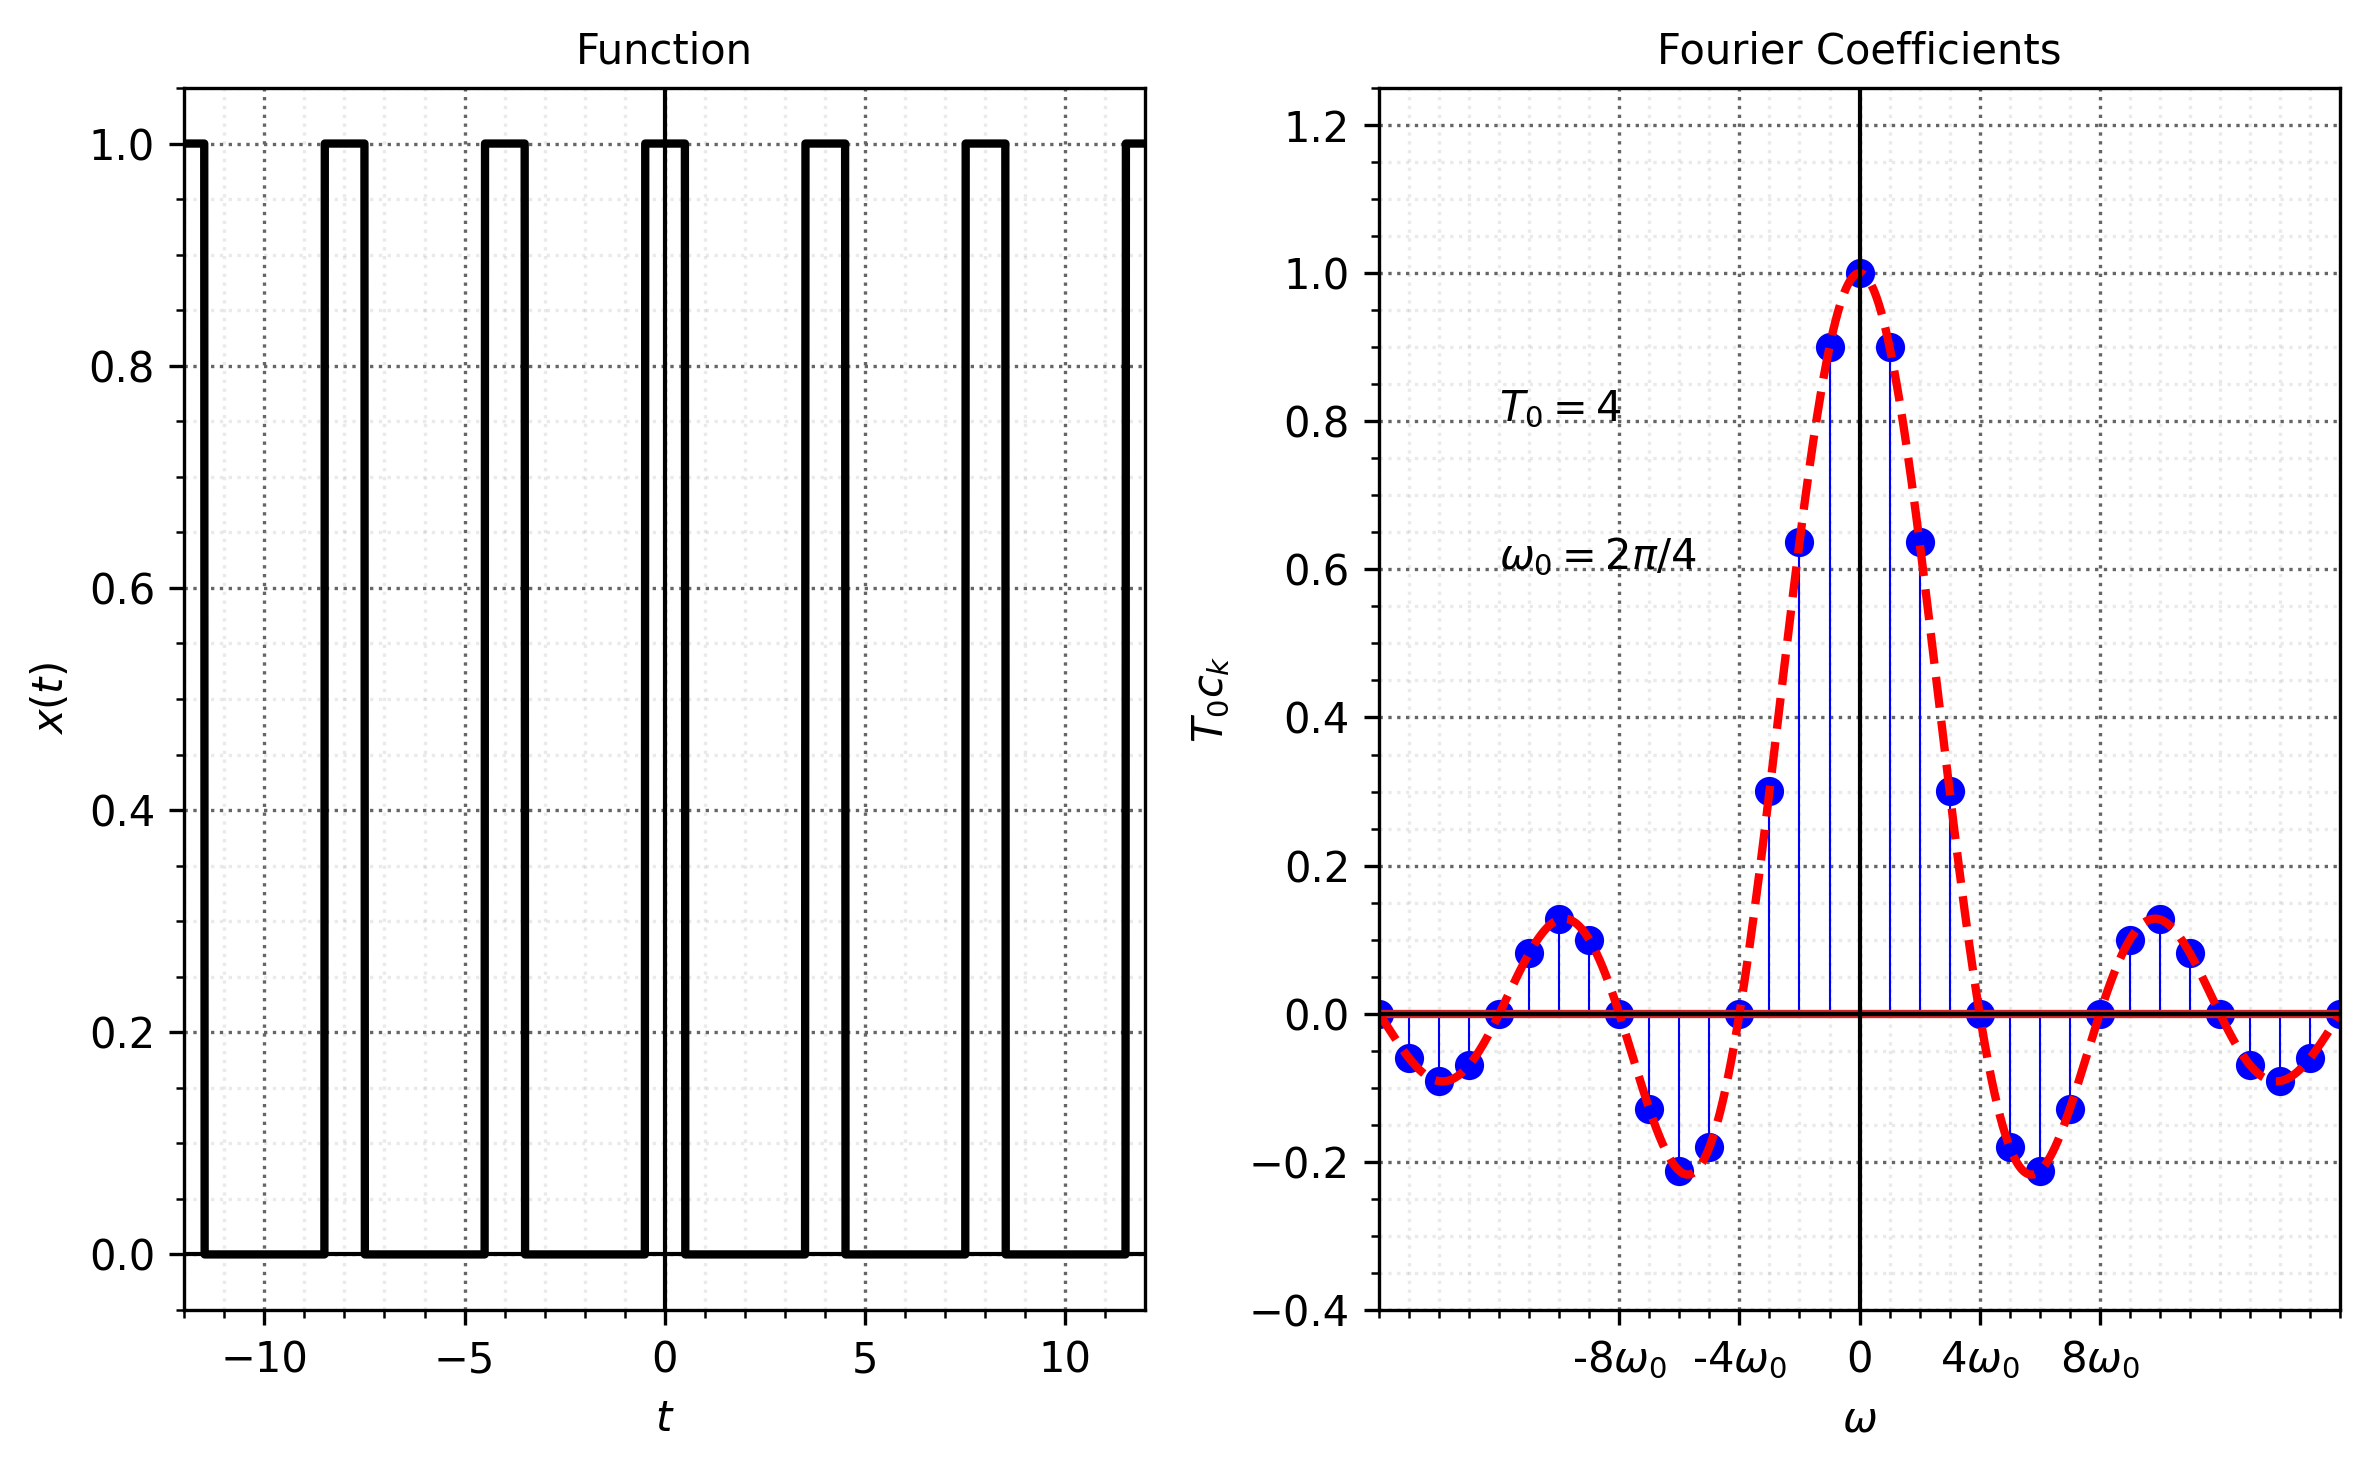

In [6]:
C_ex4 = plot_square_wave_coeffs(T0=4)

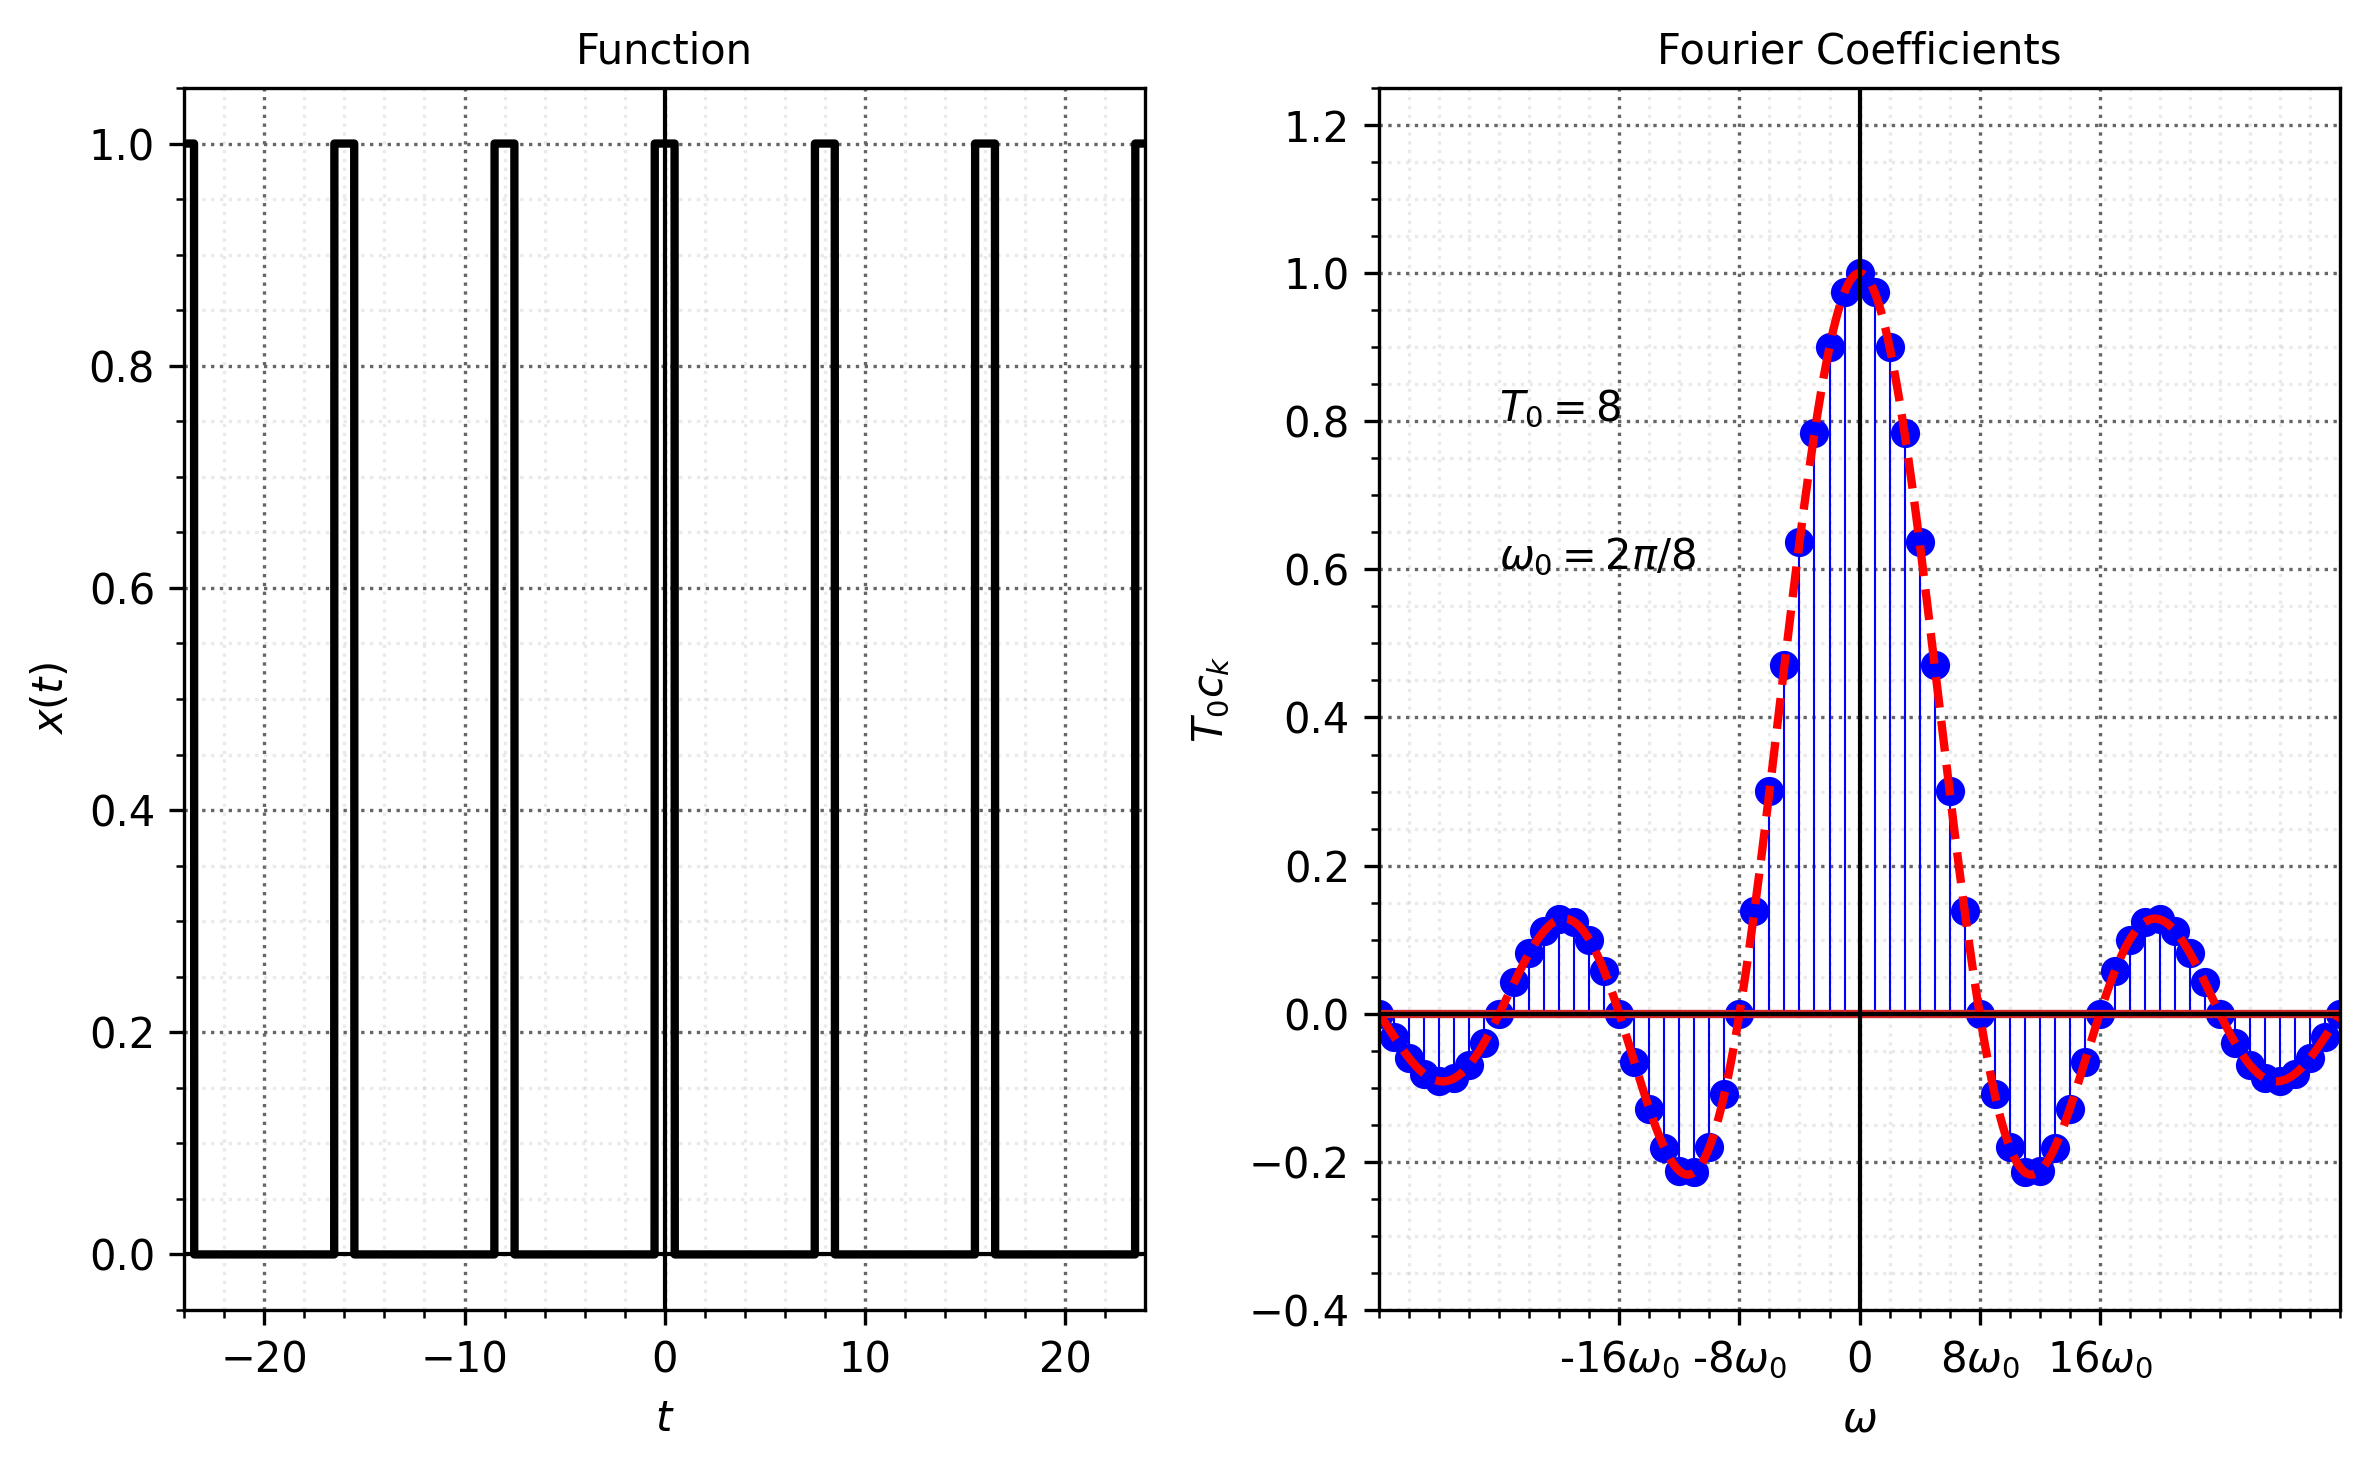

In [7]:
C_ex4 = plot_square_wave_coeffs(T0=8)

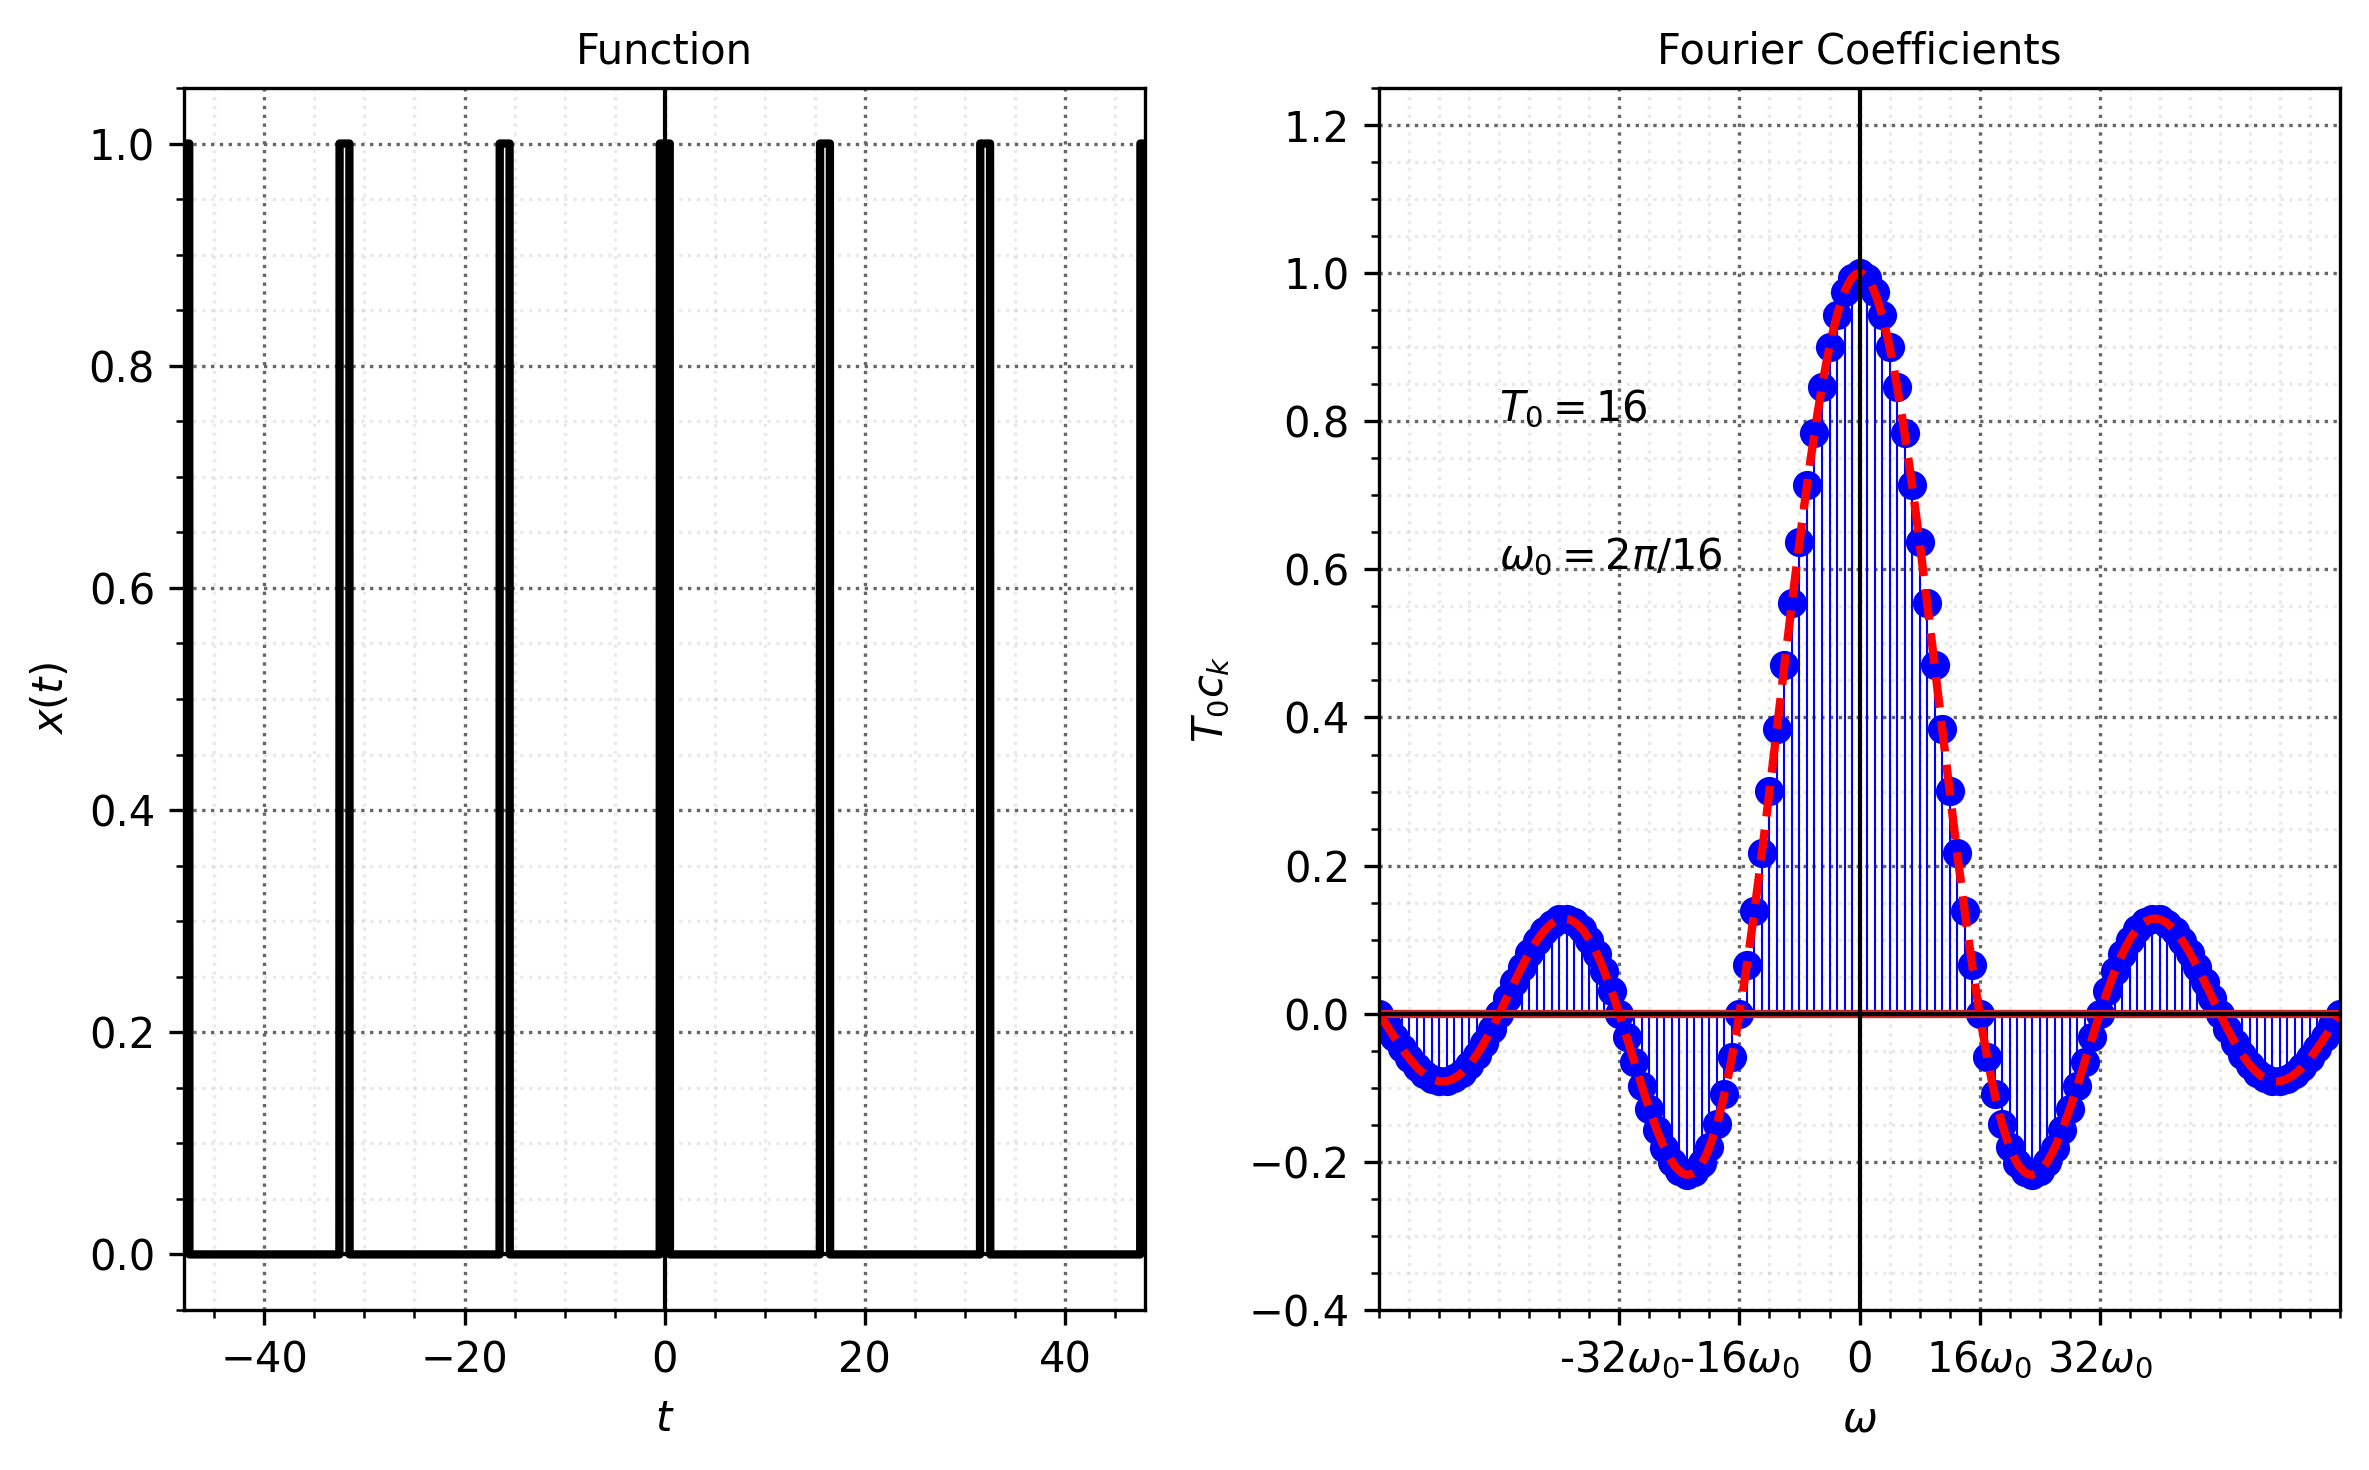

In [8]:
C_ex4 = plot_square_wave_coeffs(T0=16)

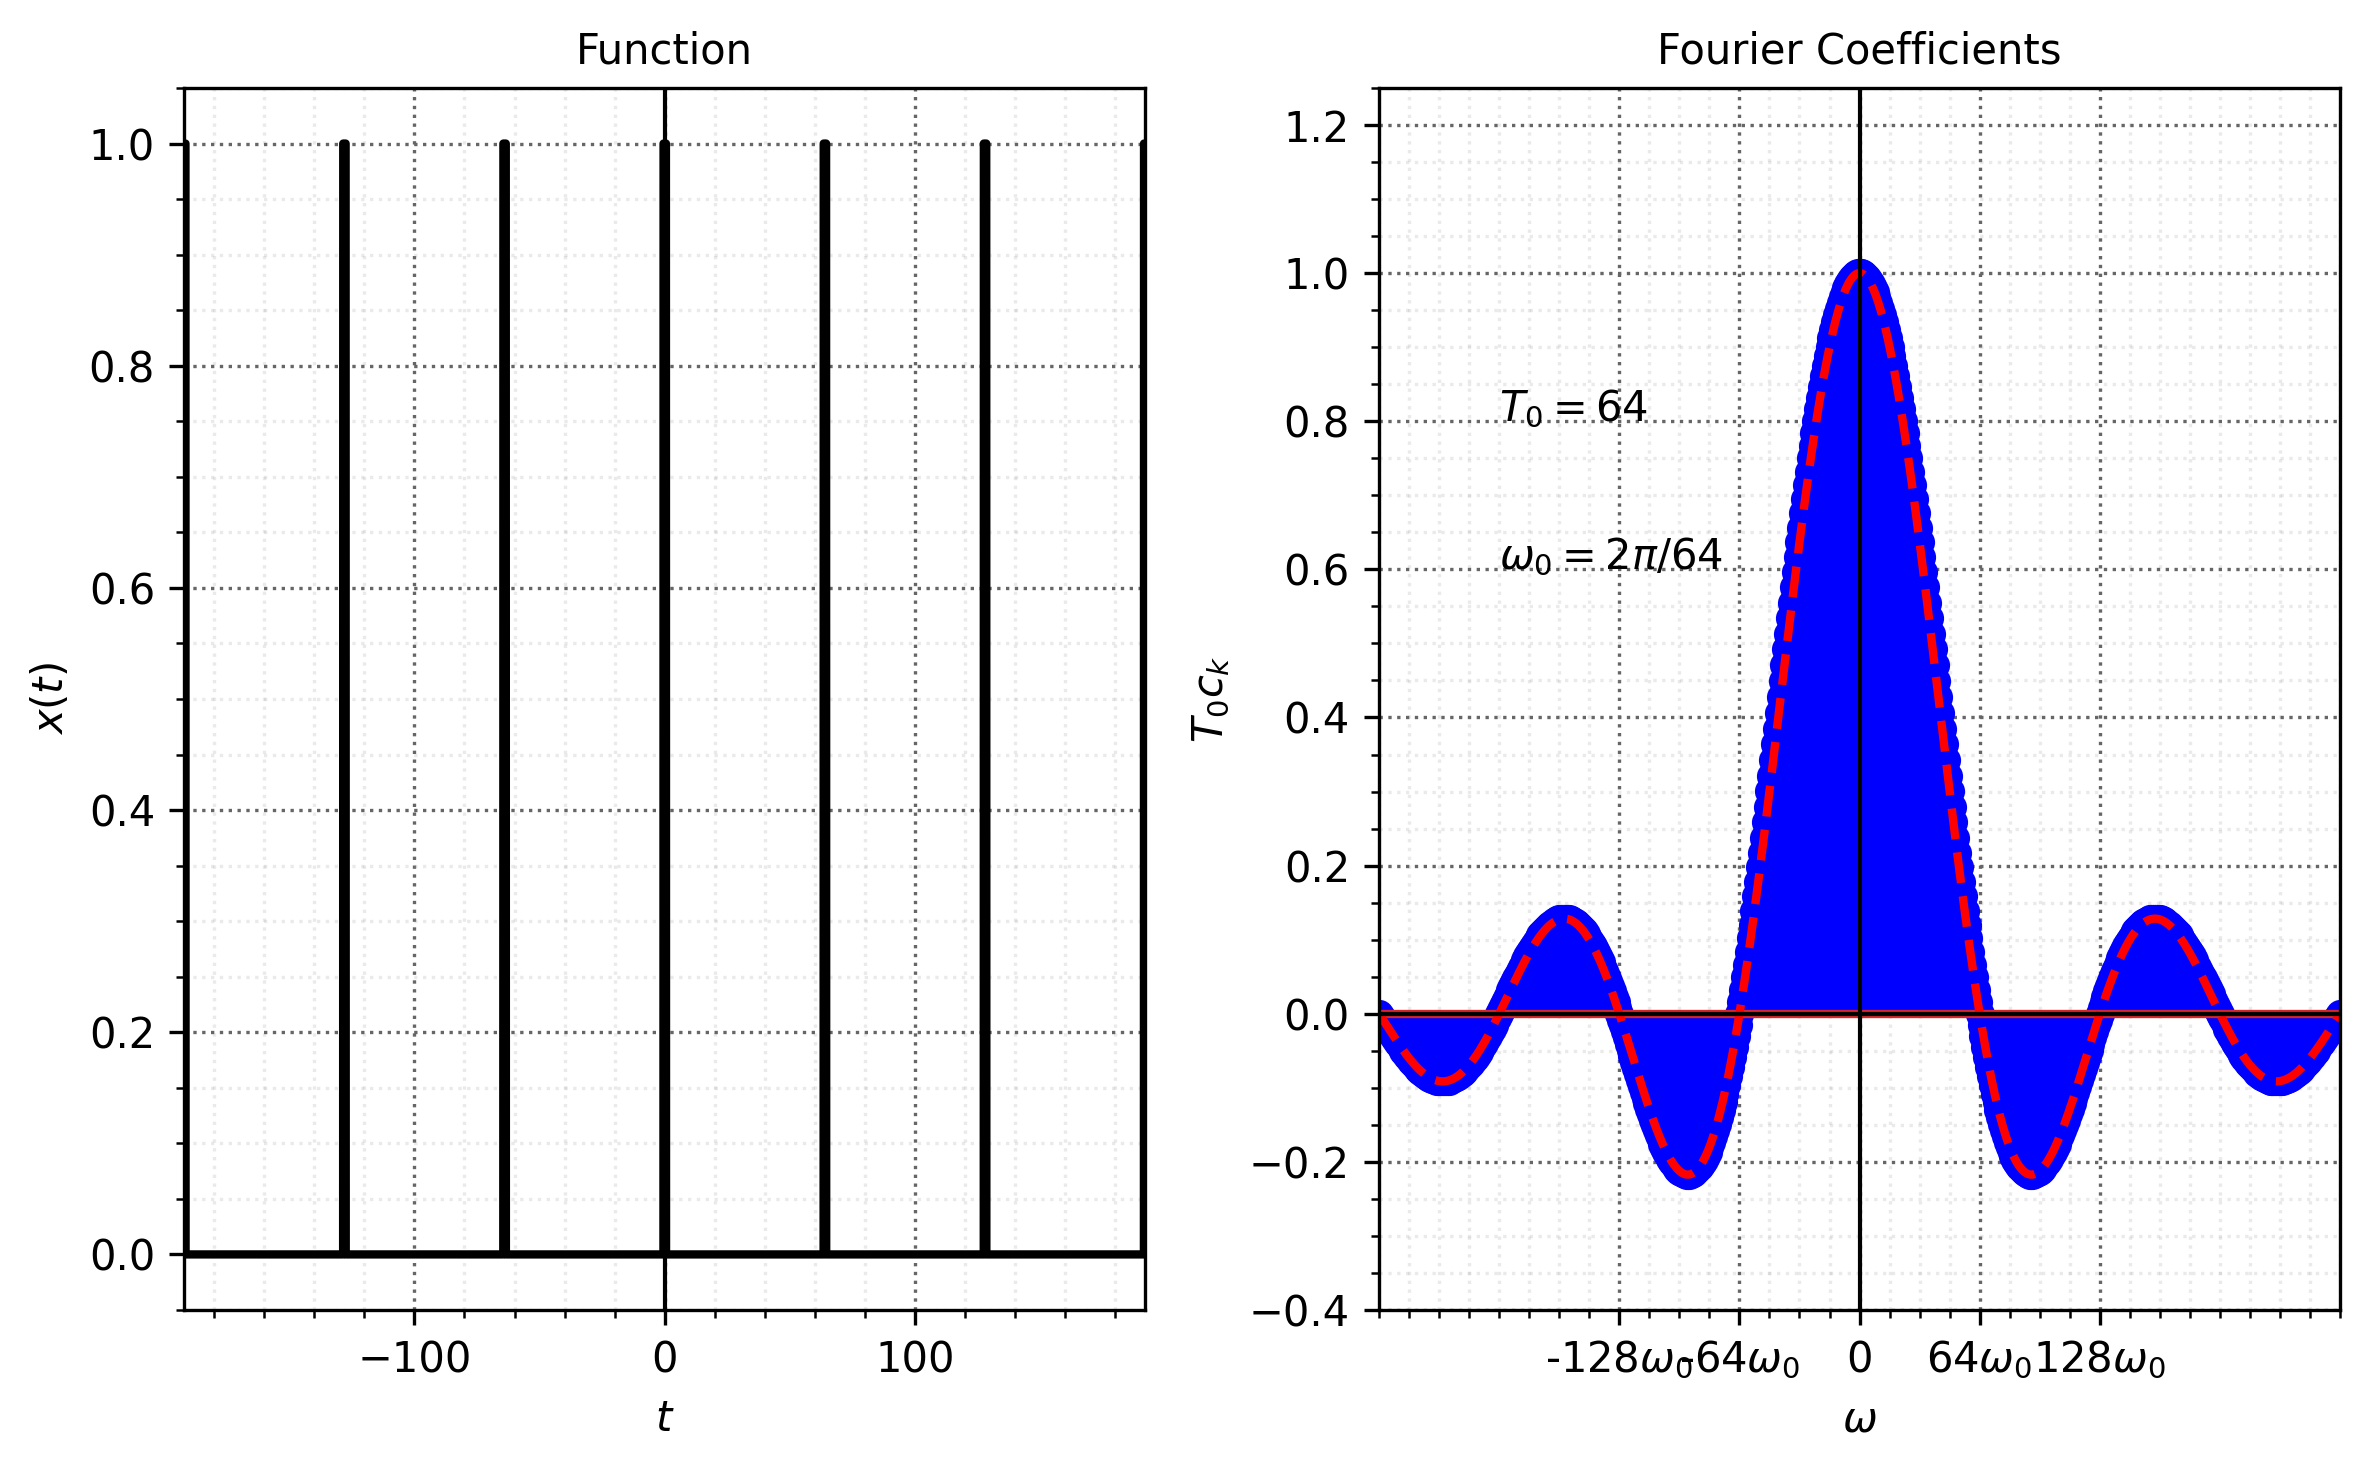

In [9]:
C_ex4 = plot_square_wave_coeffs(T0=64)